In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [50]:
url="http://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [51]:
x = df[['displacement']]
y = df['mpg']
print("Missing values in",x.isnull().sum())
print("Missing values in mpg:",y.isnull().sum())

Missing values in displacement    0
dtype: int64
Missing values in mpg: 0


In [52]:
data = df[['displacement','mpg']].dropna()

x = data[['displacement']]
y = data['mpg']

print("Feature:")
print(x.head())
print("\nTarget:")
print(y.head())

Feature:
   displacement
0         307.0
1         350.0
2         318.0
3         304.0
4         302.0

Target:
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


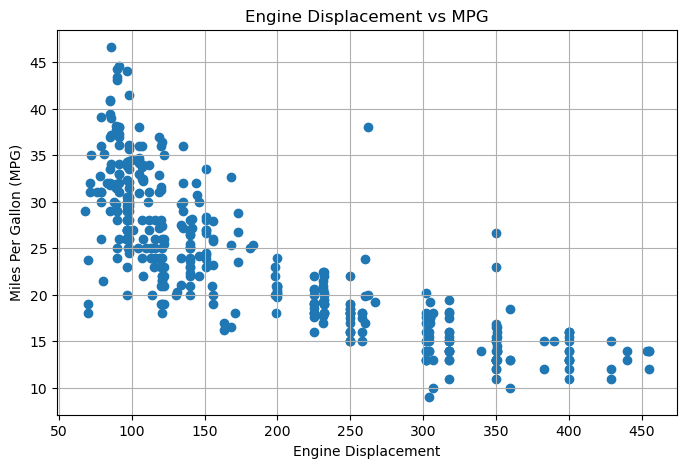

In [53]:
plt.figure(figsize=(8,5))
plt.scatter(x,y)
plt.xlabel("Engine Displacement")
plt.ylabel("Miles Per Gallon (MPG)")
plt.title("Engine Displacement vs MPG")
plt.grid(True)
plt.show()

In [54]:
x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)
print("Training samples:",len(x_train))
print("Testing samples:",len(x_test))

Training samples: 318
Testing samples: 80


In [55]:
linear_model = LinearRegression()
linear_model.fit(x_train,y_train)
y_pred_linear = linear_model.predict(x_test)

In [56]:
mse_linear = mean_squared_error(y_test,y_pred_linear)
r2_linear = r2_score(y_test,y_pred_linear)
print("Linear Regression Results")
print("-------------------------")
print("MSE:",mse_linear)
print("R-squared:",r2_linear)

Linear Regression Results
-------------------------
MSE: 18.102543998358946
R-squared: 0.6633114869465595


In [70]:
results =[]
polynomial_models ={}
results.append({
    'Model':'Linear Regression',
    'Degree':1,
    'MSE':mse_linear,
    'R_squared': r2_linear
})

for degree in range(2,6):
    
    poly = PolynomialFeatures(degree=degree)
    
    x_train_poly = poly.fit_transform(x_train)
    x_test_poly = poly.transform(x_test)
    poly_model = LinearRegression()

    poly_model.fit(x_train_poly,y_train)

    y_pred_poly = poly_model.predict(x_test_poly)

    mse = mean_squared_error(y_test,y_pred_poly)
    r2 = r2_score(y_test,y_pred_poly)

    results.append({
    'Model':'Polynomial Regression',
    'Degree':degree,
    'MSE':mse,
    'R-squared':r2
    })
polynomial_models[degree] = {
    'poly':poly,
    'model':poly_model
}
results_df = pd.DataFrame(results)
results_df

,Model,Degree,MSE,R_squared,R-squared
0,Linear Regression,1,18.102544,0.663311,NaN
1,Polynomial Regression,2,15.107354,NaN,0.719019
2,Polynomial Regression,3,14.943632,NaN,0.722064
3,Polynomial Regression,4,14.961487,NaN,0.721732
4,Polynomial Regression,5,15.230896,NaN,0.716721


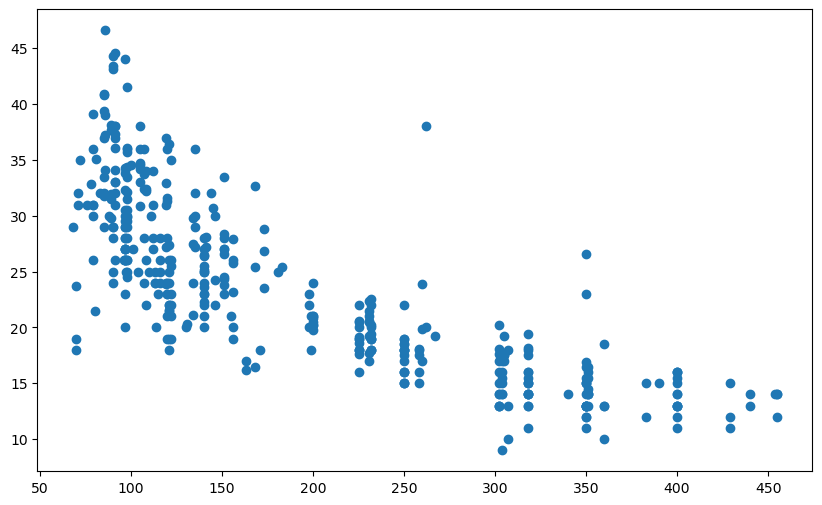

In [58]:
x_plot = pd.DataFrame({
    'displacement':np.linspace(
        x['displacement'].min(),
        x['displacement'].max(),
        300)
})

plt.figure(figsize=(10,6))

plt.scatter(
    x['displacement'],
    y,
    label='Actual Data'
)

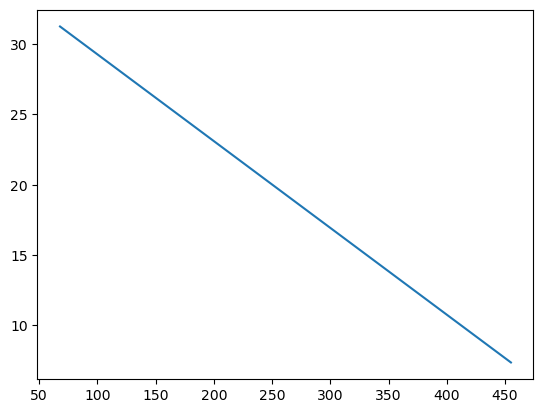

In [59]:
y_plot_linear = linear_model.predict(x_plot)
plt.plot(
    x_plot['displacement'],
    y_plot_linear,
    label='Linear Regression'
)

In [73]:
for degree in range(2,6):
    poly = polynomial_models[degree]['poly']
    poly_model = polynomial_models[degree]['model']
    x_plot_poly = poly.transform(x_plot)
    y_plot_poly = poly_model.predict(x_plot_poly)
    
    plt.plot(
    x_plot['displacement'],
    y_plot_poly,
    label=f'Polynomial Degree {degree}'
    )
plt.xlabel('Engine Displacement')
plt.ylabel('Miles Per Gallon (MPG)')

plt.title(
    'Linear and Polynomial Regression: Displacement vs MPG'
)

plt.legend()
plt.grid(True)
plt.show()

KeyError: 2

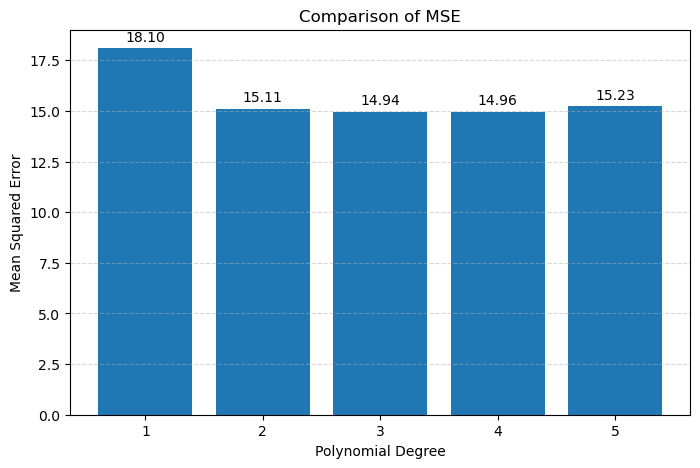

In [79]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
bars = plt.bar(
    results_df['Degree'].astype(str),
    results_df['MSE']
)
plt.bar_label(bars,fmt='%.2f',padding=3)

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Comparison of MSE")
plt.grid(axis = 'y',linestyle = '--', alpha =0.5)
plt.show()

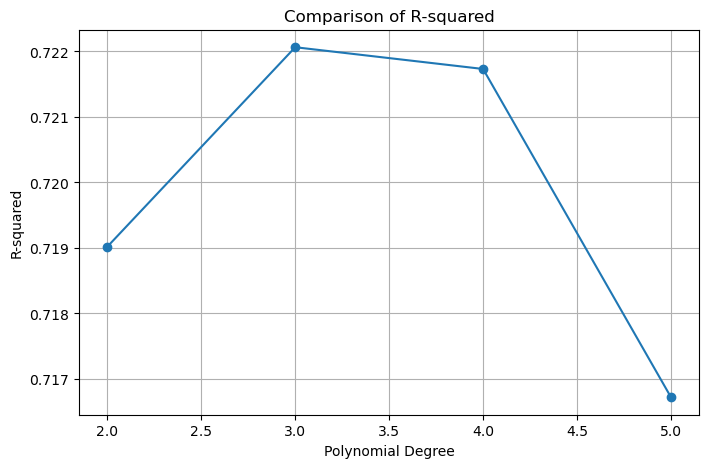

In [80]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df['Degree'],
    results_df['R-squared'],
    marker='o'
)
plt.xlabel("Polynomial Degree")
plt.ylabel("R-squared")
plt.title("Comparison of R-squared")

plt.grid(True)
plt.show()